In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyprojroot import find_root, has_file

# 1. Identify project root and establish path to the training savepoint
ROOT = find_root(has_file(".gitignore"))
training_dir = ROOT / "training"

# 2. Load the scaled training features matrix (2D DataFrame)
X_train = pd.read_csv(training_dir / "X_train_scaled.csv")

# 3. Load the training target vector and squeeze it back into a 1D Pandas Series
# This prevents Scikit-Learn from throwing DataConversionWarnings during model training
Y_train = pd.read_csv(training_dir / "Y_train.csv").squeeze("columns")

In [2]:
# --- Hyperparameters ---
# 1. The step size used at each iteration to update the model weights during optimization
learning_rate = 0.01

# 2. Total number of complete passes through the training dataset during gradient descent
epochs = 100000

# 3. Intervals at which optimization metrics (e.g., loss, weights) will be logged or tracked
epoch_rate = np.arange(0, epochs, 100)

# --- Model Parameters ---
# 4. Initialize parameters vector with ones for your 8 features (from California Housing)
# These will be updated iteratively as the model minimizes the loss function
weights = np.ones(8)

In [3]:

def compute_predictions(inputs, weights):
    """
    Computes the linear regression predictions (hypothesis) for a given feature matrix.
    
    Formula: y_hat = X . W (Dot product of input features and model weights)
    """
    # 1. Calculate the dot product between the input matrix and the weights vector
    # Using the '@' operator is the clean, modern standard for matrix multiplication in Python.
    # Input shape:  [n_samples, 8]
    # Weight shape: [8,]
    # Output shape: [n_samples,] (A flat 1D sequence of predictions)
    predictions = inputs @ weights
    
    return predictions

In [4]:
def MSE_Calculation(predictions, actuals):
    """
    Calculates the Mean Squared Error (MSE) cost function.
    
    Measures the average squared variance between model predictions and true targets.
    """
    # 1. Compute the element-wise squared differences (residuals)
    # Squaring removes negative signs and heavily penalizes larger forecasting errors
    summed_squared_errors = (predictions - actuals) ** 2
    
    # 2. Calculate the arithmetic mean of the squared errors to get the final cost scalar
    MSE = summed_squared_errors.mean()
    
    return MSE

In [5]:

def compute_gradient(input, predictions, actuals):
    """
    Computes the partial derivatives (gradients) of the MSE cost function 
    with respect to the model weights.
    
    Formula: Gradient = (1 / n) * X^T . (y_hat - y)
    """
    # 1. Calculate the raw prediction error (residuals vector)
    # Shape: [n_samples,]
    errors = predictions - actuals
    
    # 2. Compute the dot product of the transposed features and the errors vector,
    # then average the result by dividing by the total number of samples.
    # Matrix Math: [8, n_samples] @ [n_samples,] -> Output Shape: [8,]
    gradient = (input.T @ errors) / len(actuals)
    
    return gradient

In [6]:
def update_weights(weights, gradient, learning_rate):
    """
    Performs a single gradient descent optimization step to update model parameters.
    
    Formula: W_new = W_old - (α * ∂J/∂W)
    """
    # 1. Shift the weight vector in the opposite direction of the steepest ascent (the gradient).
    # Scaling the gradient by the learning_rate determines the physical step size taken.
    updated_weights = weights - (gradient * learning_rate)
    
    return updated_weights

In [7]:

def train_loop(input, weights, actuals, epochs, learning_rate):
    """
    Executes batch gradient descent optimization over a specified number of epochs.
    
    Iteratively minimizes Mean Squared Error by updating model parameters 
    along the calculated error gradient.
    """
    # Initialize an empty list to track cost progression histories
    MSE_rate = []
    
    # Iterate across the complete optimization horizon using clean 0-based tracking
    for i in range(epochs):
        
        # 1. Forward Pass: Generate current model predictions (X @ W)
        predictions = compute_predictions(input, weights)
        
        # 2. Loss Tracking: Compute the Mean Squared Error for this iteration
        MSE = MSE_Calculation(predictions, actuals)
        
        # 3. Backward Pass: Calculate the cost surface partial derivatives (gradients)
        gradient = compute_gradient(input, predictions, actuals)
        
        # 4. Parameter Optimization: Shift weights down the slope of the error surface
        weights = update_weights(weights, gradient, learning_rate)
        
        # 5. Logging Cadence: Capture and print metrics exactly every 100 epochs
        if i % 100 == 0:
            print("Epoch: ", i)
            print("MSE:   ", MSE)
            # print("Updated Weights: ", weights)
            
            # Save the scalar loss value to analyze the learning curve stability
            MSE_rate.append(MSE)
    
    return MSE_rate, weights

In [8]:
def test_loop(input, weights, actuals):
    """
    Evaluates the finalized model weights against an independent test/validation dataset.
    
    Provides an unbiased evaluation of model generalization and out-of-sample performance.
    """
    # 1. Forward Pass: Generate predictions using the optimized, frozen weight matrix
    # No gradients are calculated here; the weights are strictly read-only
    predictions = compute_predictions(input, weights)
    
    # 2. Generalization Metric: Calculate the final testing Mean Squared Error
    # Comparing this value against your final training MSE reveals if your model overfit
    MSE = MSE_Calculation(predictions, actuals)
        
    return MSE

Epoch:  0
MSE:    11.007123703446627
Epoch:  100
MSE:    5.7511697827517745
Epoch:  200
MSE:    5.269969484058071
Epoch:  300
MSE:    5.151756749077432
Epoch:  400
MSE:    5.094988113605473
Epoch:  500
MSE:    5.054950986876568
Epoch:  600
MSE:    5.022352356957105
Epoch:  700
MSE:    4.9946233288742325
Epoch:  800
MSE:    4.9707198451625425
Epoch:  900
MSE:    4.950019264843641
Epoch:  1000
MSE:    4.932055539196319
Epoch:  1100
MSE:    4.916446313323168
Epoch:  1200
MSE:    4.90286795752924
Epoch:  1300
MSE:    4.8910437229234285
Epoch:  1400
MSE:    4.880736095588547
Epoch:  1500
MSE:    4.8717409184021365
Epoch:  1600
MSE:    4.863882543286175
Epoch:  1700
MSE:    4.8570097357380515
Epoch:  1800
MSE:    4.850992187310508
Epoch:  1900
MSE:    4.845717537707948
Epoch:  2000
MSE:    4.841088829281439
Epoch:  2100
MSE:    4.8370223298740145
Epoch:  2200
MSE:    4.833445669898507
Epoch:  2300
MSE:    4.830296247644224
Epoch:  2400
MSE:    4.8275198636277405
Epoch:  2500
MSE:    4.825069

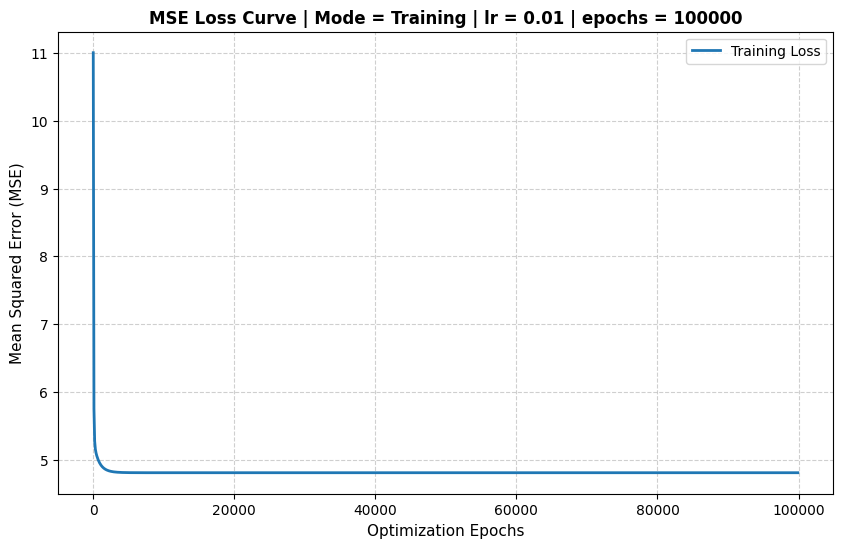

In [9]:

# 1. Execute Batch Gradient Descent Optimization Loop
# Explicitly passing raw numpy views ensures position-based matrix operations run cleanly
MSE_rate, finalized_weights = train_loop(
    input=X_train.to_numpy(), 
    weights=weights, 
    actuals=Y_train.to_numpy(), 
    epochs=epochs, 
    learning_rate=learning_rate
)
    
# 2. Plotting the Learning Curve
# This visualizes how rapidly the cost function decreases over the training horizon
plt.figure(figsize=(10, 6))
plt.plot(epoch_rate, MSE_rate, label="Training Loss", color="#1f77b4", linewidth=2)

# 3. Labeling and Formatting the Visual Diagnostics
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.xlabel("Optimization Epochs", fontsize=11)
plt.title(
    f"MSE Loss Curve | Mode = Training | lr = {learning_rate} | epochs = {epochs}", 
    fontsize=12, 
    fontweight="bold"
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# 4. Output Serialization
# Persists your newly generated learning curve chart directly into the plots asset directory
plt.savefig(ROOT / "plots" / "Train_MSE_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# 1. Ingest test assets, explicitly flattening the target vector to 1D
X_test = pd.read_csv(training_dir / "X_test_scaled.csv")
Y_test = pd.read_csv(training_dir / "Y_test.csv").squeeze("columns")

# 2. Compute out-of-sample performance metrics using optimized parameters
MSE = test_loop(X_test.to_numpy(), finalized_weights, Y_test.to_numpy())
print(f"Test MSE: {MSE:.5f}")

# 3. Scale metric down to original target units
RMSE = MSE ** 0.5
print(f"RMSE:     {RMSE:.5f}")

Test MSE: 4.80709
RMSE:     2.19251
